# Creating Bivariate Scatterplots

In [2]:
import geopandas as gpd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [3]:
# setting wd 
import os
os.chdir('/users/bkung/fooddesertproject')

In [6]:
# loading in data 
def read_county_data(county_name):
    gdf = gpd.read_file(f"extra_figures/modeling_data/{county_name}_modeling_final.gpkg")
    return gdf 

harris_data = read_county_data("harris")
bexar_data = read_county_data("bexar")
travis_data = read_county_data("travis")
dallas_data = read_county_data("dallas")
tarrant_data = read_county_data("tarrant")

In [11]:
harris_gdf = gpd.GeoDataFrame(harris_data)
bexar_gdf = gpd.GeoDataFrame(bexar_data)
travis_gdf = gpd.GeoDataFrame(travis_data) 
dallas_gdf = gpd.GeoDataFrame(dallas_data)
tarrant_gdf = gpd.GeoDataFrame(tarrant_data) 

bexar_clean = bexar_data.dropna().copy()
travis_clean = travis_data.dropna().copy()
harris_clean = harris_data.dropna().copy()
dallas_clean = dallas_data.dropna().copy()
tarrant_clean = tarrant_data.dropna().copy()

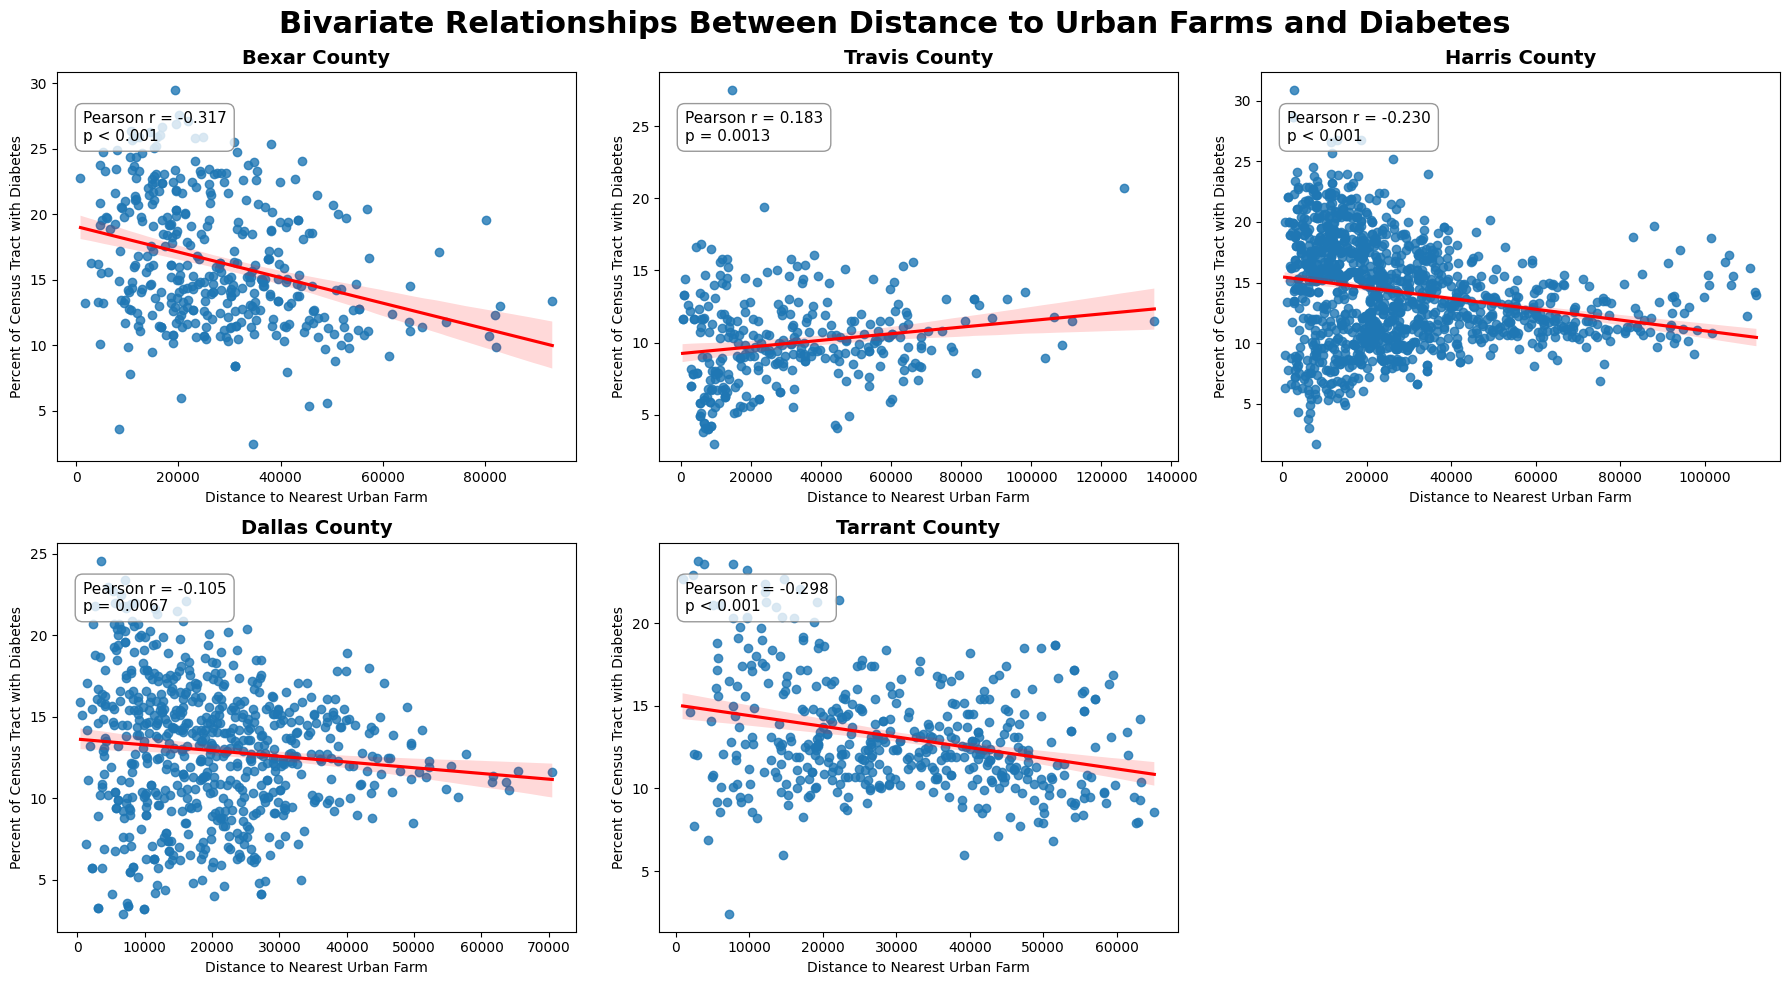

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# defining title names for each county
title_names = [
    "Bexar County",
    "Travis County",
    "Harris County",
    "Dallas County",
    "Tarrant County",
]

# defining datasets to pull from
dfs = [bexar_gdf, travis_gdf, harris_gdf, dallas_gdf, tarrant_gdf]

# setting up grid layout
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# looping and plotting scatterplot on each respective axis
for i, df in enumerate(dfs):
    current_ax = axes[i]

    # 1. Clean data to avoid NaNs breaking pearsonr
    clean_data = df[["distance_to_nearest_uf", "E_DIABETES"]].dropna()

    # 2. Calculate Pearson correlation coefficient & p-value
    r, p_val = pearsonr(
        clean_data["distance_to_nearest_uf"], clean_data["E_DIABETES"]
    )

    # 3. Draw scatterplot
    sns.regplot(
        data=clean_data,
        x="distance_to_nearest_uf",
        y="E_DIABETES",
        ci=95,
        line_kws={"color": "red"},
        ax=current_ax,
    )

    # 4. Format p-value string nicely
    p_str = f"p = {p_val:.4f}" if p_val >= 0.001 else "p < 0.001"

    # 5. Add stats box in top-right or top-left corner
    current_ax.text(
        0.05,
        0.90,
        f"Pearson r = {r:.3f}\n{p_str}",
        transform=current_ax.transAxes,
        fontsize=11,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round,pad=0.5", facecolor="white", alpha=0.8, edgecolor="gray"
        ),
    )

    # titles and labels
    current_ax.set_title(title_names[i], fontsize=14, fontweight="bold")
    current_ax.set_xlabel("Distance to Nearest Urban Farm")
    current_ax.set_ylabel("Percent of Census Tract with Diabetes")

# deleting empty 6th slot
fig.delaxes(axes[5])

# overarching title
fig.suptitle(
    "Bivariate Relationships Between Distance to Urban Farms and Diabetes",
    fontsize=22,
    fontweight="bold",
    y=0.98,
)

# fixing layout and saving
fig.tight_layout()
plt.savefig(
    "final_figures/Figure_5/bivariate_scatterplots.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()